實驗資料夾： .\MT-GSGCN
找到檔案：
   train_curve_human1.csv
   train_curve_human2.csv
   train_curve_human3.csv
   train_curve_human4.csv
   train_curve_human5.csv
   train_curve_human6.csv
   train_curve_human7.csv
   train_curve_human8.csv
   train_curve_human9.csv
   train_curve_human10.csv
Loaded 10 folds, 80 epochs each.


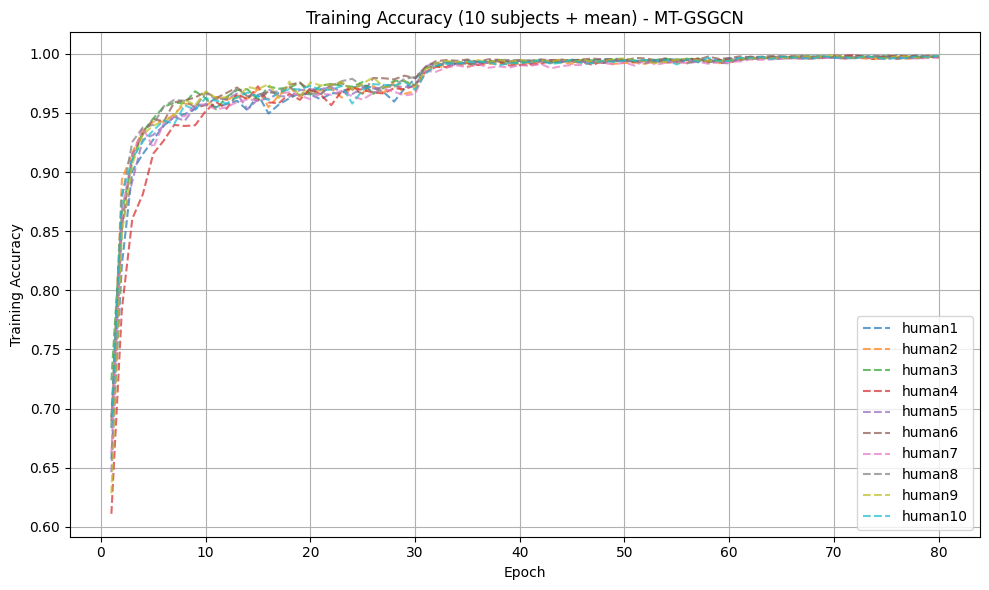

已儲存： .\MT-GSGCN\train_acc_loso_10subjects.png


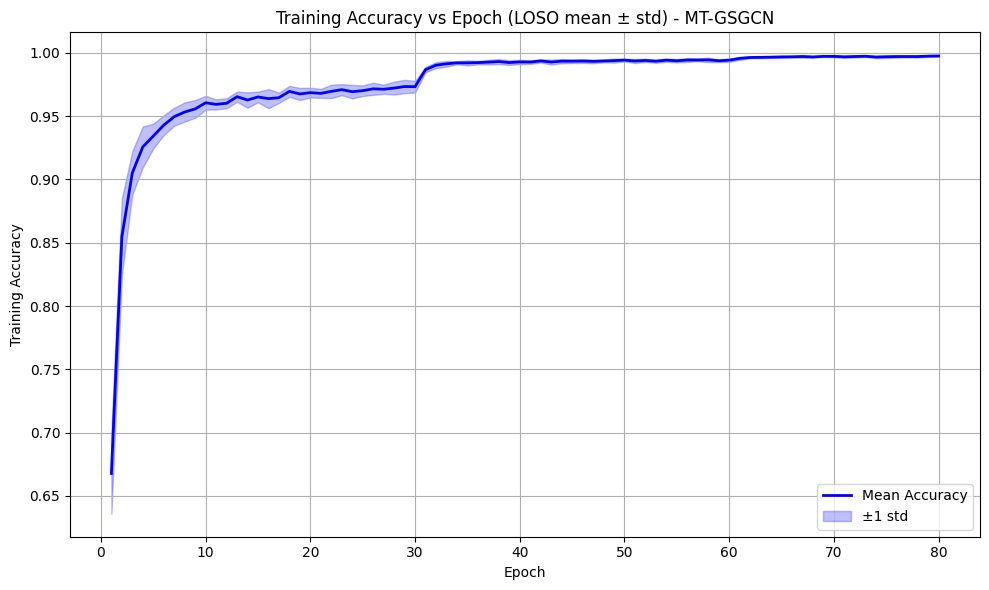

已儲存： .\MT-GSGCN\train_acc_loso_mean_std.png
已儲存： .\MT-GSGCN\train_acc_loso_mean_std.csv
✅ 訓練準確率圖完成！


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os, re

# ============================
#  設定要處理哪個實驗資料夾
# ============================

experiment_name = "MT-GSGCN"
base_path = os.path.join(".", experiment_name)

print("實驗資料夾：", base_path)

# ============================
#  找到所有 train_curve_humanX.csv
# ============================

file_paths = sorted(
    glob.glob(os.path.join(base_path, "train_curve_human*.csv")),
    key=lambda x: int(re.search(r"human(\d+)", x).group(1))
)

print("找到檔案：")
for fp in file_paths:
    print("  ", os.path.basename(fp))

if not file_paths:
    raise RuntimeError("找不到任何 train_curve_human*.csv")

all_acc = []
epochs = None

# ============================
#   自動偵測 Accuracy 欄位名稱
# ============================

def detect_acc_column(df):
    """
    自動找準確率欄位：
      - acc, accuracy, train_acc, train_accuracy
      - train_acc(%)
      - 任何包含 'acc' 的欄位
    """
    for col in df.columns:
        if "acc" in col.lower():  # 最強偵測方式
            return col
    # 若找不到就抓第二欄
    return df.columns[1]


# ============================
#       讀取所有 CSV
# ============================

for fp in file_paths:
    df = pd.read_csv(fp)

    acc_col = detect_acc_column(df)
    acc_values = df[acc_col].values

    # 若格式為百分比（例如 93.56...），轉成 0–1
    if acc_values.max() > 1.5:  
        acc_values = acc_values / 100.0

    all_acc.append(acc_values)

    # 取得 epoch
    if epochs is None:
        if "epoch" in df.columns:
            epochs = df["epoch"].values
        else:
            epochs = np.arange(len(acc_values))

all_acc = np.array(all_acc)
num_folds, num_epochs = all_acc.shape
print(f"Loaded {num_folds} folds, {num_epochs} epochs each.")

# ============================
#  圖片 1：10 subjects Accuracy 曲線
# ============================

plt.figure(figsize=(10, 6))

for i in range(num_folds):
    plt.plot(epochs, all_acc[i], alpha=0.7, linestyle='--', label=f"human{i+1}")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title(f"Training Accuracy (10 subjects + mean) - {experiment_name}")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
out_png1 = os.path.join(base_path, "train_acc_loso_10subjects.png")
plt.savefig(out_png1, dpi=300)
plt.show()

print("已儲存：", out_png1)

# ============================
#  圖片 2：平均 ± 標準差
# ============================

mean_acc = all_acc.mean(axis=0)
std_acc  = all_acc.std(axis=0)

plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, color='blue', linewidth=2, label="Mean Accuracy")
plt.fill_between(epochs, mean_acc - std_acc, mean_acc + std_acc,
                 color='blue', alpha=0.25, label="±1 std")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title(f"Training Accuracy vs Epoch (LOSO mean ± std) - {experiment_name}")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
out_png2 = os.path.join(base_path, "train_acc_loso_mean_std.png")
plt.savefig(out_png2, dpi=300)
plt.show()

print("已儲存：", out_png2)

# ============================
#  也輸出成 CSV
# ============================

df_out = pd.DataFrame({
    "epoch": epochs,
    "mean_acc": mean_acc,
    "std_acc": std_acc
})
out_csv = os.path.join(base_path, "train_acc_loso_mean_std.csv")
df_out.to_csv(out_csv, index=False)

print("已儲存：", out_csv)
print("✅ 訓練準確率圖完成！")


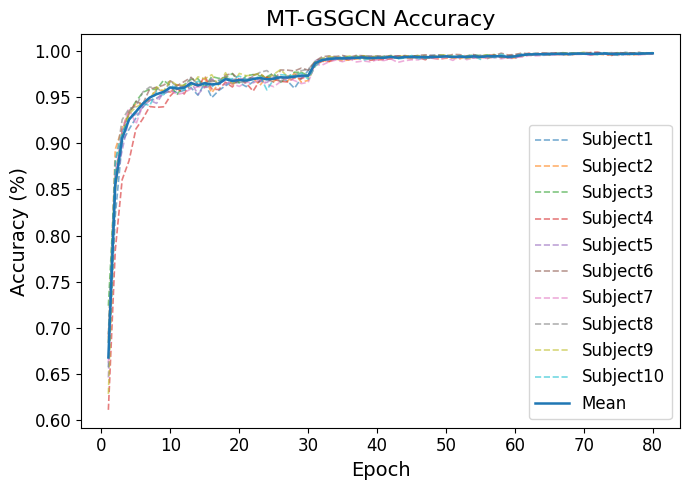

已儲存： .\MT-GSGCN\train_acc_loso_10subjects_with_mean_clean.png


In [3]:
# ============================
#  圖片 1：10 subjects Accuracy 虛線 + 平均實線（無背景格線）
# ============================

plt.figure(figsize=(7, 5))

# 10 subjects accuracy（虛線）
for i in range(num_folds):
    plt.plot(
        epochs, all_acc[i],
        alpha=0.6,
        linestyle='--',
        linewidth=1.2,
        label=f"Subject{i+1}"
    )

# ============================
#  平均 Accuracy（藍色實線）
# ============================

mean_acc = all_acc.mean(axis=0)

plt.plot(
    epochs, mean_acc,
    color='tab:blue',        # Matplotlib 預設藍色
    linewidth=1.8,
    label="Mean",
    zorder=10
)

# ===== 字體放大 =====
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title(f"{experiment_name} Accuracy", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc="lower right", fontsize=12)

# 去除背景格線
plt.grid(False)

plt.tight_layout()

out_png1 = os.path.join(base_path, "train_acc_loso_10subjects_with_mean_clean.png")
plt.savefig(out_png1, dpi=300, transparent=False)
plt.show()

print("已儲存：", out_png1)


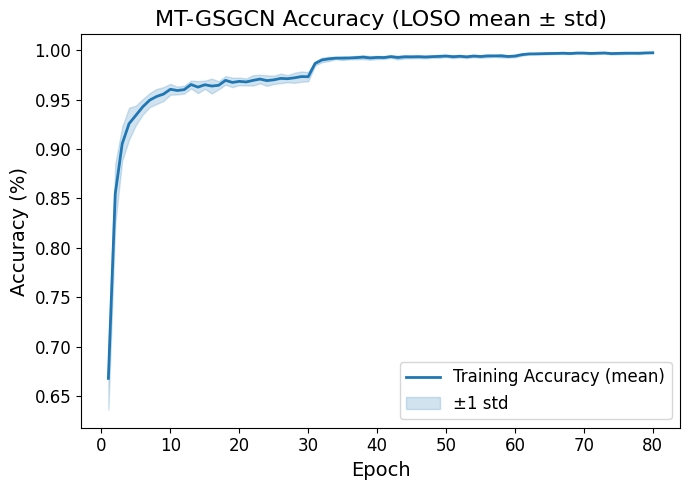

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 假設你已有 all_acc (10 × epochs)
# all_acc = np.array(acc_curves)

epochs = np.arange(1, all_acc.shape[1] + 1)

# 計算平均與標準差
mean_acc = all_acc.mean(axis=0)
std_acc  = all_acc.std(axis=0)

# 畫圖
plt.figure(figsize=(7,5))

plt.plot(
    epochs, mean_acc,
    color='tab:blue',        # 與 Loss 圖一致的預設藍色
    linewidth=2.0,
    label="Training Accuracy (mean)"
)

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    color='tab:blue',
    alpha=0.2,
    label="±1 std"
)

# ===== 統一字體大小 =====
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title("MT-GSGCN Accuracy (LOSO mean ± std)", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc="lower right", fontsize=12)

plt.grid(False)
plt.tight_layout()

plt.savefig("train_acc_loso_mean_std.png", dpi=300)
plt.show()


實驗資料夾： .\MT-GSGCN-CBAM
找到檔案：
   train_curve_human1.csv
   train_curve_human2.csv
   train_curve_human3.csv
   train_curve_human4.csv
   train_curve_human5.csv
   train_curve_human6.csv
   train_curve_human7.csv
   train_curve_human8.csv
   train_curve_human9.csv
   train_curve_human10.csv
Loaded 10 folds, 80 epochs each.


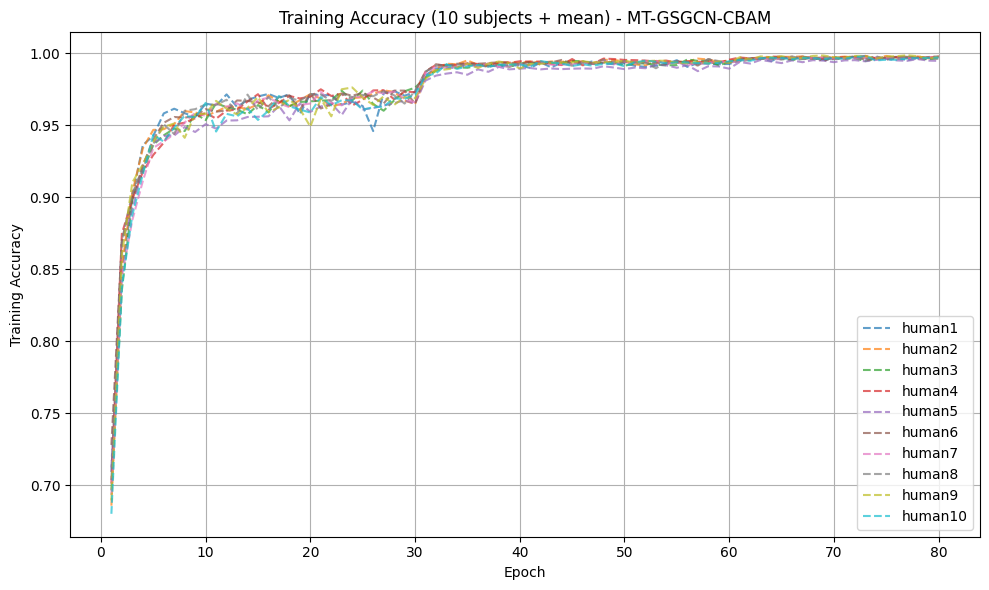

已儲存： .\MT-GSGCN-CBAM\train_acc_loso_10subjects.png


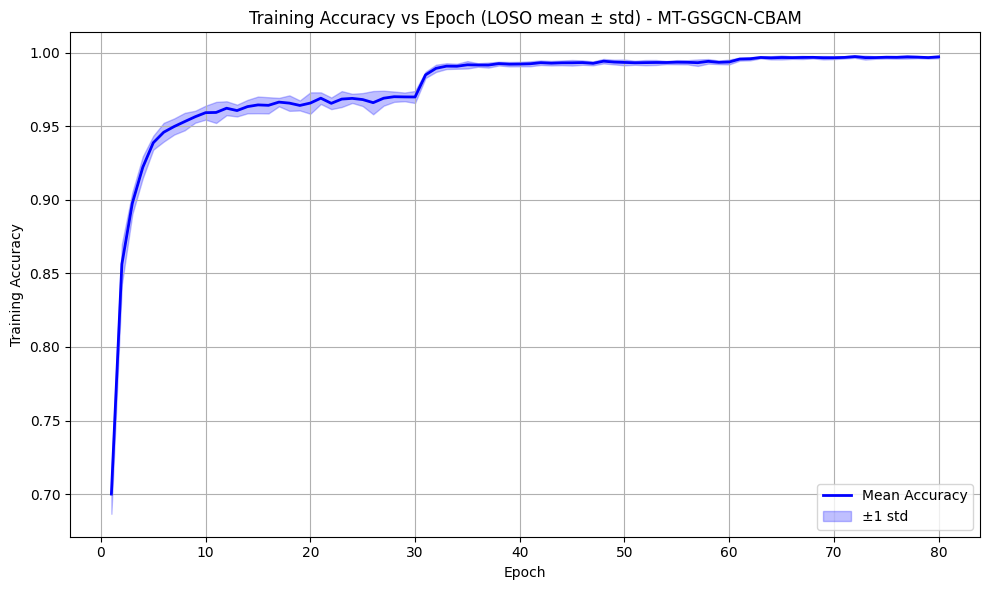

已儲存： .\MT-GSGCN-CBAM\train_acc_loso_mean_std.png
已儲存： .\MT-GSGCN-CBAM\train_acc_loso_mean_std.csv
✅ 訓練準確率圖完成！


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os, re

# ============================
#  設定要處理哪個實驗資料夾
# ============================

experiment_name = "MT-GSGCN-CBAM"
base_path = os.path.join(".", experiment_name)

print("實驗資料夾：", base_path)

# ============================
#  找到所有 train_curve_humanX.csv
# ============================

file_paths = sorted(
    glob.glob(os.path.join(base_path, "train_curve_human*.csv")),
    key=lambda x: int(re.search(r"human(\d+)", x).group(1))
)

print("找到檔案：")
for fp in file_paths:
    print("  ", os.path.basename(fp))

if not file_paths:
    raise RuntimeError("找不到任何 train_curve_human*.csv")

all_acc = []
epochs = None

# ============================
#   自動偵測 Accuracy 欄位名稱
# ============================

def detect_acc_column(df):
    """
    自動找準確率欄位：
      - acc, accuracy, train_acc, train_accuracy
      - train_acc(%)
      - 任何包含 'acc' 的欄位
    """
    for col in df.columns:
        if "acc" in col.lower():  # 最強偵測方式
            return col
    # 若找不到就抓第二欄
    return df.columns[1]


# ============================
#       讀取所有 CSV
# ============================

for fp in file_paths:
    df = pd.read_csv(fp)

    acc_col = detect_acc_column(df)
    acc_values = df[acc_col].values

    # 若格式為百分比（例如 93.56...），轉成 0–1
    if acc_values.max() > 1.5:  
        acc_values = acc_values / 100.0

    all_acc.append(acc_values)

    # 取得 epoch
    if epochs is None:
        if "epoch" in df.columns:
            epochs = df["epoch"].values
        else:
            epochs = np.arange(len(acc_values))

all_acc = np.array(all_acc)
num_folds, num_epochs = all_acc.shape
print(f"Loaded {num_folds} folds, {num_epochs} epochs each.")

# ============================
#  圖片 1：10 subjects Accuracy 曲線
# ============================

plt.figure(figsize=(10, 6))

for i in range(num_folds):
    plt.plot(epochs, all_acc[i], alpha=0.7, linestyle='--', label=f"human{i+1}")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title(f"Training Accuracy (10 subjects + mean) - {experiment_name}")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
out_png1 = os.path.join(base_path, "train_acc_loso_10subjects.png")
plt.savefig(out_png1, dpi=300)
plt.show()

print("已儲存：", out_png1)

# ============================
#  圖片 2：平均 ± 標準差
# ============================

mean_acc = all_acc.mean(axis=0)
std_acc  = all_acc.std(axis=0)

plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_acc, color='blue', linewidth=2, label="Mean Accuracy")
plt.fill_between(epochs, mean_acc - std_acc, mean_acc + std_acc,
                 color='blue', alpha=0.25, label="±1 std")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title(f"Training Accuracy vs Epoch (LOSO mean ± std) - {experiment_name}")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
out_png2 = os.path.join(base_path, "train_acc_loso_mean_std.png")
plt.savefig(out_png2, dpi=300)
plt.show()

print("已儲存：", out_png2)

# ============================
#  也輸出成 CSV
# ============================

df_out = pd.DataFrame({
    "epoch": epochs,
    "mean_acc": mean_acc,
    "std_acc": std_acc
})
out_csv = os.path.join(base_path, "train_acc_loso_mean_std.csv")
df_out.to_csv(out_csv, index=False)

print("已儲存：", out_csv)
print("✅ 訓練準確率圖完成！")


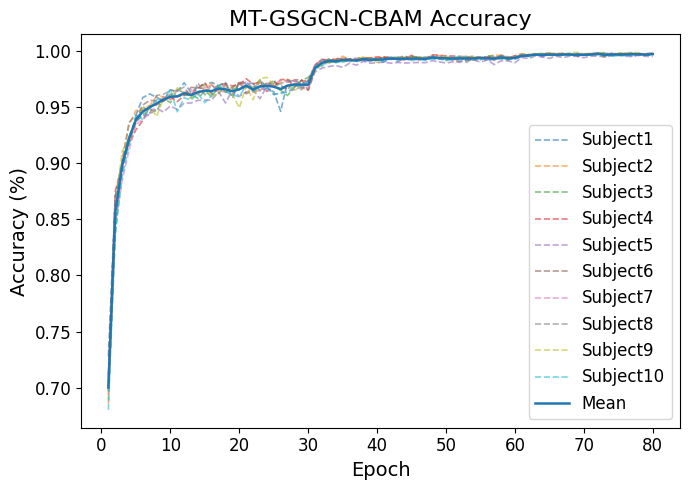

已儲存： .\MT-GSGCN-CBAM\train_acc_loso_10subjects_with_mean_clean.png


In [5]:
# ============================
#  圖片 1：10 subjects Accuracy 虛線 + 平均實線（無背景格線）
# ============================

plt.figure(figsize=(7, 5))

# 10 subjects accuracy（虛線）
for i in range(num_folds):
    plt.plot(
        epochs, all_acc[i],
        alpha=0.6,
        linestyle='--',
        linewidth=1.2,
        label=f"Subject{i+1}"
    )

# ============================
#  平均 Accuracy（藍色實線）
# ============================

mean_acc = all_acc.mean(axis=0)

plt.plot(
    epochs, mean_acc,
    color='tab:blue',        # Matplotlib 預設藍色，與其他圖一致
    linewidth=1.8,
    label="Mean",
    zorder=10
)

# ===== 字體放大 =====
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title(f"{experiment_name} Accuracy", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc="lower right", fontsize=12)

# 去除背景格線
plt.grid(False)

plt.tight_layout()

out_png1 = os.path.join(base_path, "train_acc_loso_10subjects_with_mean_clean.png")
plt.savefig(out_png1, dpi=300, transparent=False)
plt.show()

print("已儲存：", out_png1)


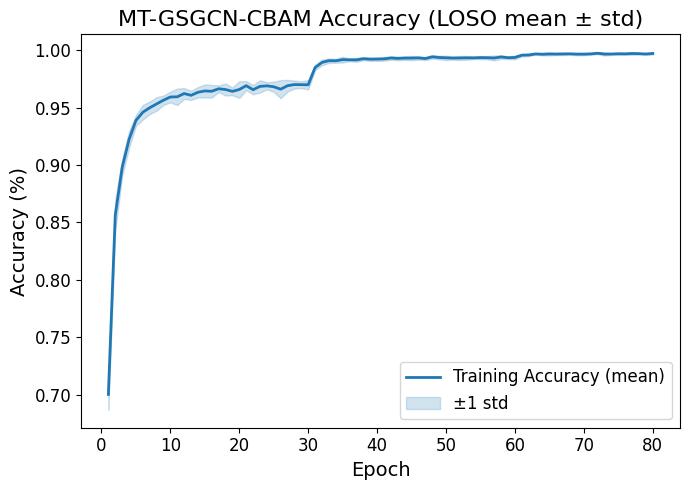

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 假設你已有 all_acc (10 × epochs)
# all_acc = np.array(acc_curves)

epochs = np.arange(1, all_acc.shape[1] + 1)

# 計算平均與標準差
mean_acc = all_acc.mean(axis=0)
std_acc  = all_acc.std(axis=0)

# 畫圖
plt.figure(figsize=(7,5))

plt.plot(
    epochs, mean_acc,
    color='tab:blue',           # 和 Loss 版本相同的藍色
    linewidth=2.0,
    label="Training Accuracy (mean)"
)

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    color='tab:blue',
    alpha=0.2,
    label="±1 std"
)

# ===== 字體放大區 =====
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title("MT-GSGCN-CBAM Accuracy (LOSO mean ± std)", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc="lower right", fontsize=12)

plt.grid(False)
plt.tight_layout()

plt.savefig("train_acc_loso_mean_std.png", dpi=300)
plt.show()
